In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('flights.csv')
df.describe()

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,flight,air_time,distance,hour,minute
count,336776.000000,336776.0,336776.000000,336776.000000,328521.000000,336776.000000,328521.000000,328063.000000,336776.000000,327346.000000,336776.000000,327346.000000,336776.000000,336776.000000,336776.000000
mean,168387.500000,2013.0,6.548510,15.710787,1349.109947,1344.254840,12.639070,1502.054999,1536.380220,6.895377,1971.923620,150.686460,1039.912604,13.180247,26.230100
std,97219.001466,0.0,3.414457,8.768607,488.281791,467.335756,40.210061,533.264132,497.457142,44.633292,1632.471938,93.688305,733.233033,4.661316,19.300846
min,0.000000,2013.0,1.000000,1.000000,1.000000,106.000000,-43.000000,1.000000,1.000000,-86.000000,1.000000,20.000000,17.000000,1.000000,0.000000
25%,84193.750000,2013.0,4.000000,8.000000,907.000000,906.000000,-5.000000,1104.000000,1124.000000,-17.000000,553.000000,82.000000,502.000000,9.000000,8.000000
50%,168387.500000,2013.0,7.000000,16.000000,1401.000000,1359.000000,-2.000000,1535.000000,1556.000000,-5.000000,1496.000000,129.000000,872.000000,13.000000,29.000000
75%,252581.250000,2013.0,10.000000,23.000000,1744.000000,1729.000000,11.000000,1940.000000,1945.000000,14.000000,3465.000000,192.000000,1389.000000,17.000000,44.000000
max,336775.000000,2013.0,12.000000,31.000000,2400.000000,2359.000000,1301.000000,2400.000000,2359.000000,1272.000000,8500.000000,695.000000,4983.000000,23.000000,59.000000


In [5]:
df.isnull().sum()

id                   0
year                 0
month                0
day                  0
dep_time          8255
sched_dep_time       0
dep_delay         8255
arr_time          8713
sched_arr_time       0
arr_delay         9430
carrier              0
flight               0
tailnum           2512
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
name                 0
dtype: int64

In [6]:
df_cleaned=df.dropna(subset=['air_time','arr_time'])
df_cleaned.isnull().sum()

id                0
year              0
month             0
day               0
dep_time          0
sched_dep_time    0
dep_delay         0
arr_time          0
sched_arr_time    0
arr_delay         0
carrier           0
flight            0
tailnum           0
origin            0
dest              0
air_time          0
distance          0
hour              0
minute            0
time_hour         0
name              0
dtype: int64

In [7]:
df_cleaned.head()

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,name
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00,JetBlue Airways
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.


Text(0.5, 0, 'mean arrival delay')

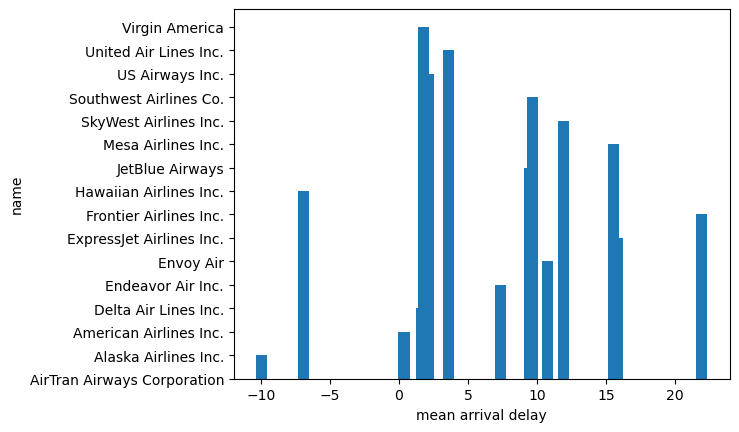

In [28]:
gr=df_cleaned.groupby('name')['arr_delay'].mean().reset_index()
gr.columns=['name','mean_arr_delay']
plt.bar(gr['mean_arr_delay'],gr['name'])
plt.ylabel('name')
plt.xlabel('mean arrival delay')

In [9]:
df_time=df_cleaned.groupby('hour')['hour'].count().reset_index(name='sum')
df_time.columns=['hour','sum']

Text(0.5, 1.0, 'The most air-traffic in each hour in a day')

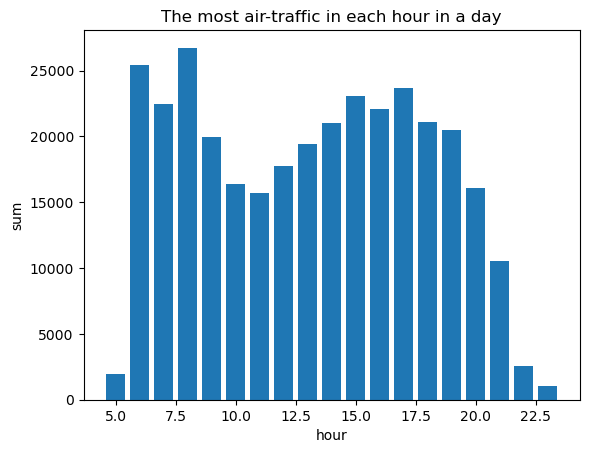

In [30]:
plt.bar(df_time['hour'],df_time['sum'])
plt.xlabel('hour')
plt.ylabel('sum')
plt.title('The most air-traffic in each hour in a day')

In [12]:
df_cleaned=df_cleaned.copy()
df_cleaned.loc[:,'traffic']=df_cleaned.groupby(['origin','dest'])['name'].transform('count')

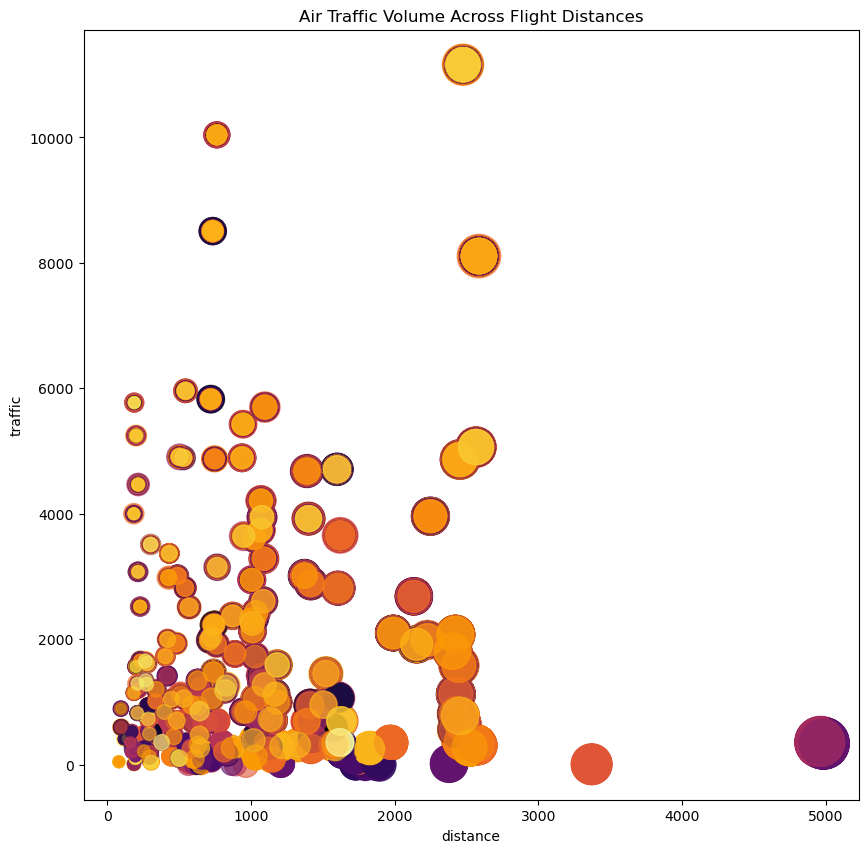

In [13]:
plt.figure(figsize=(10,10))
plt.scatter(df_cleaned['distance'],df_cleaned['traffic'],c=df_cleaned['hour'],s=df_cleaned['air_time']*2,cmap="inferno", alpha=0.6)
plt.xlabel('distance')
plt.ylabel('traffic')
plt.title('Air Traffic Volume Across Flight Distances')
plt.show()

Text(0.5, 1.0, 'Correlation Matrix of Key Flight Features')

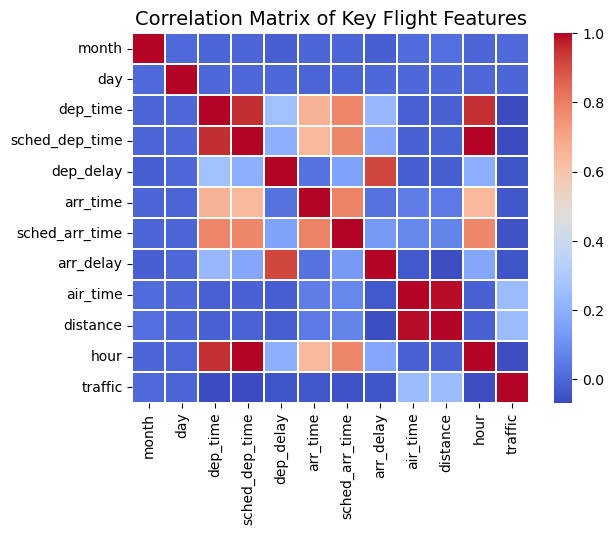

In [14]:
df_import=df_cleaned[['month','day','dep_time','sched_dep_time','dep_delay','arr_time','sched_arr_time','arr_delay','air_time','distance','hour','traffic']]
sns.heatmap(df_import.corr() ,fmt=".3f",cmap='coolwarm', linewidth=.3)
plt.title('Correlation Matrix of Key Flight Features', fontsize=14)